**Lecture des données**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split,cross_val_score,cross_validate,learning_curve
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay
# Lecture des données
df = pd.read_csv('/content/ecommerce_product_performance.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Product_Price       1900 non-null   float64
 1   Discount_Rate       1900 non-null   float64
 2   Product_Rating      1900 non-null   float64
 3   Number_of_Reviews   1900 non-null   float64
 4   Stock_Availability  1900 non-null   float64
 5   Days_to_Deliver     1900 non-null   float64
 6   Return_Rate         1900 non-null   float64
 7   Category_ID         1900 non-null   float64
dtypes: float64(8)
memory usage: 125.1 KB


In [ ]:
df.shape

(2000, 8)

In [ ]:
df.duplicated().sum()

np.int64(0)

**gestion des valeurs manquantes**

In [ ]:
df.isna().sum()

,0
Product_Price,100
Discount_Rate,100
Product_Rating,100
Number_of_Reviews,100
Stock_Availability,100
Days_to_Deliver,100
Return_Rate,100
Category_ID,100


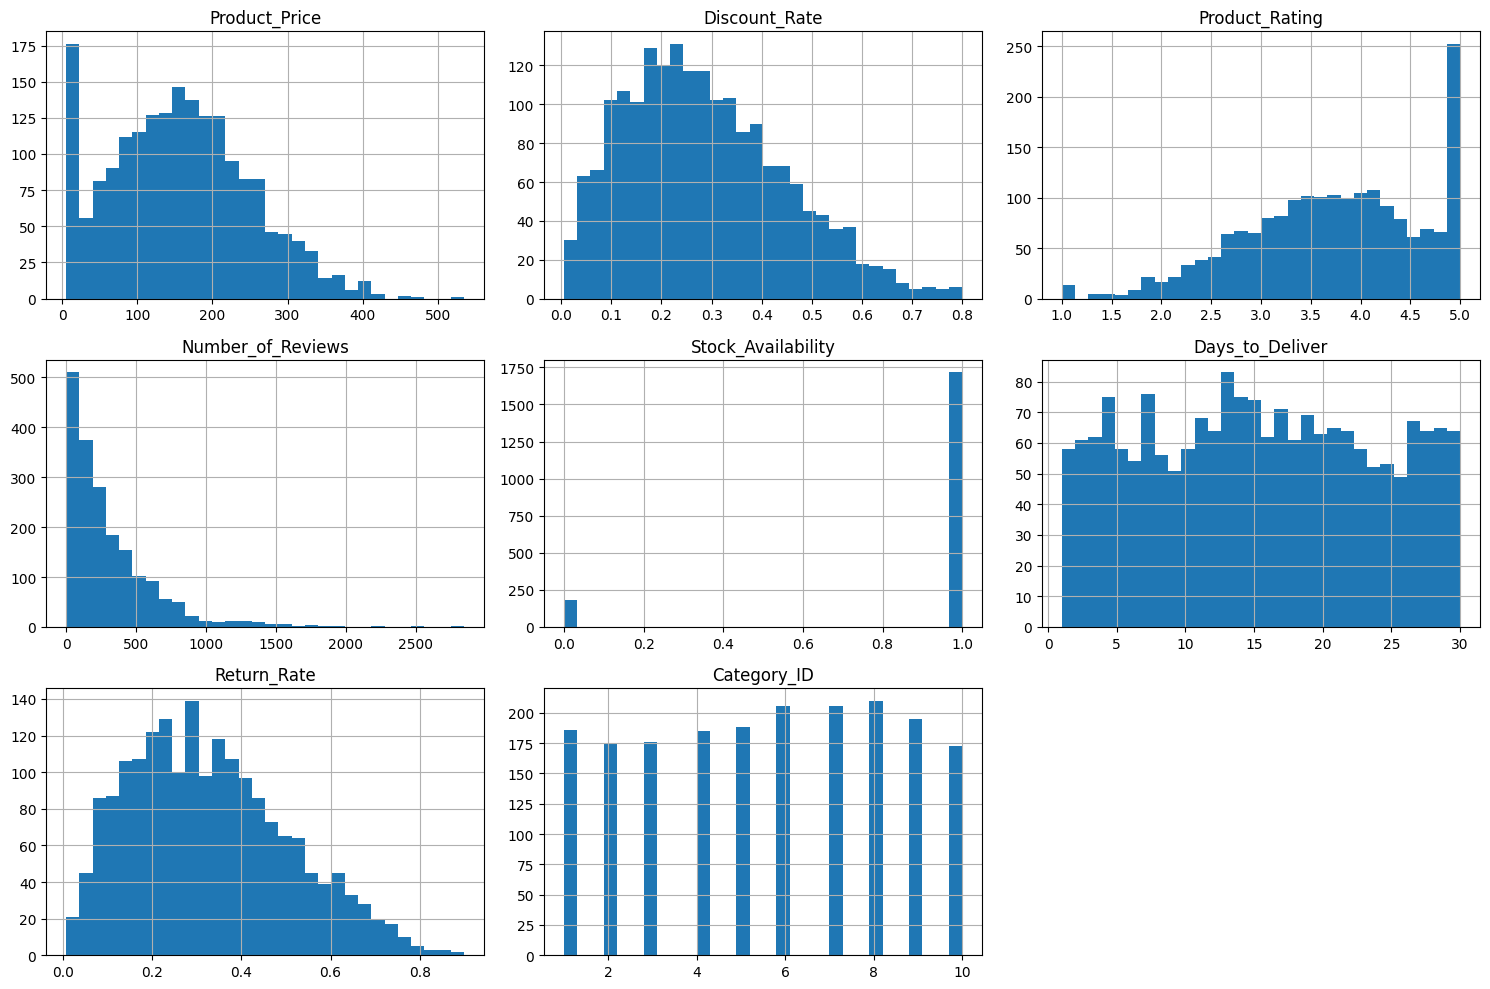

In [ ]:
#histogramme des variables
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

In [ ]:
#imputation de la médiane aux valeurs manquantes des variables quantitatives
df['Discount_Rate'] = df['Discount_Rate'].fillna(df['Discount_Rate'].median())
df['Product_Rating'] = df['Product_Rating'].fillna(df['Product_Rating'].median())
df['Number_of_Reviews'] = df['Number_of_Reviews'].fillna(df['Number_of_Reviews'].median())
df['Days_to_Deliver'] = df['Days_to_Deliver'].fillna(df['Days_to_Deliver'].median())
df['Return_Rate'] = df['Return_Rate'].fillna(df['Return_Rate'].median())
#imputation du mode  aux valeurs manquantes de la variable qualitative
df['Stock_Availability']=df['Stock_Availability'].fillna(df['Stock_Availability'].mode()[0])


In [ ]:
# Imputer les valeurs manquantes de la colonne « Product_Price » à l'aide du prix médian de chaque catégorie dans « Category_ID »
# Mais avant nous allons supprimer les lignes null de Category_ID pour empecher un regroupement par valeurs Null Nous perdront uniquement 5% des données
df=df.dropna(subset='Category_ID')

# Regrouper par Category_ID et calculer la médiane de Product_Price pour chaque catégorie
category_medians = df.groupby('Category_ID')['Product_Price'].transform('median')

# Créer un masque pour les lignes où la colonne Product_Price est vide
mask = df['Product_Price'].isna()

# Remplacer les valeurs manquantes par la médiane de leur catégorie respective
df.loc[mask, 'Product_Price'] = category_medians[mask]

In [ ]:
df.isnull().sum()

,0
Product_Price,0
Discount_Rate,0
Product_Rating,0
Number_of_Reviews,0
Stock_Availability,0
Days_to_Deliver,0
Return_Rate,0
Category_ID,0


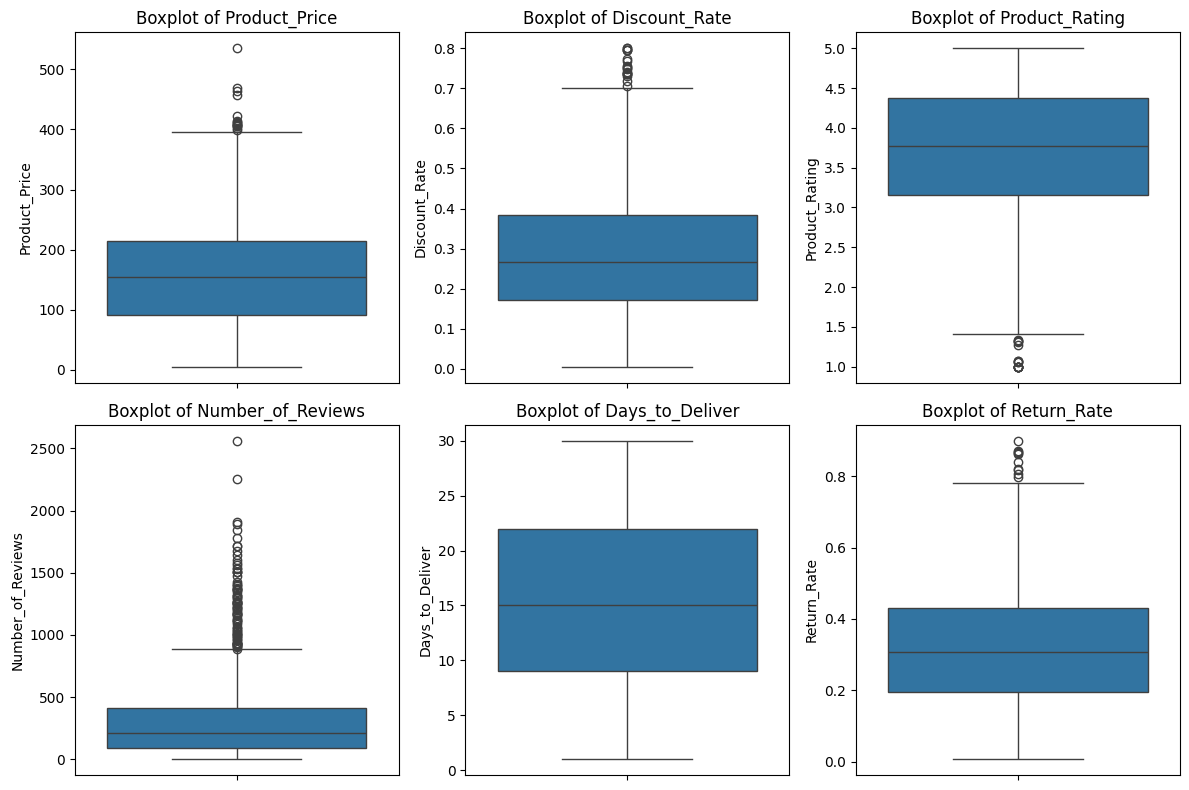

In [ ]:
# Generate boxplots for numerical columns
import matplotlib.pyplot as plt
import seaborn as sns
numerical_cols = ['Product_Price', 'Discount_Rate', 'Product_Rating', 'Number_of_Reviews',
                 'Days_to_Deliver', 'Return_Rate']
plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [ ]:
# convertir les variables aux types appropriés
df['Number_of_Reviews'] = df['Number_of_Reviews'].astype('int64')
#df['Stock_Availability'] = df['Stock_Availability'].astype(bool)
df['Days_to_Deliver'] = df['Days_to_Deliver'].astype('int64')

# Vcérification des types
print("types des données après conversion:")
print(df.dtypes)

types des données après conversion:
Product_Price         float64
Discount_Rate         float64
Product_Rating        float64
Number_of_Reviews       int64
Stock_Availability    float64
Days_to_Deliver         int64
Return_Rate           float64
Category_ID           float64
dtype: object


**Suppression de la variable Category_ID du dataset pour la suite des analyses**

In [ ]:
df = df.drop('Category_ID', axis=1)

In [ ]:
df.describe()

,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate
count,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000
mean,157.139150,0.285914,3.728844,299.680000,0.906842,15.437895,0.326356
std,91.327612,0.155134,0.862957,299.821579,0.290730,8.309814,0.172395
min,5.000000,0.005368,1.000000,0.000000,0.000000,1.000000,0.006528
25%,91.918718,0.170818,3.162544,94.000000,1.000000,9.000000,0.195240
50%,153.929758,0.265994,3.770215,210.000000,1.000000,15.000000,0.307430
75%,214.731909,0.384950,4.371012,411.000000,1.000000,22.000000,0.430654
max,535.273149,0.800000,5.000000,2562.000000,1.000000,30.000000,0.900000


In [ ]:
from sklearn.model_selection import train_test_split

# Correction : Utilisation de 'df' qui est la variable définie dans le kernel
# La colonne cible est 'Cluster' générée précédemment
X = df.drop(['Cluster'], axis=1)
y = df['Cluster']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Taille du jeu d'entraînement : {len(X_train)}")
print(f"Taille du jeu de test : {len(X_test)}")
print("Distribution des classes dans y_train :\n", y_train.value_counts(normalize=True))

KeyError: "['Cluster'] not found in axis"

In [ ]:
'''# Performant est équivalent à une note >=moyenne des notes et Taux de retour <=taux moyen
# On pourrait ajouter un nombre d'avis supérieur a la médiane ou bien tout autre combinaison

mean_rating = df['Product_Rating'].mean()
mean_return = df['Return_Rate'].mean()
print(mean_rating,mean_return)
# Construction de la variable cible
df['Performant'] = ((df['Product_Rating'] >= mean_rating) &  (df['Return_Rate'] <= mean_return)).astype(int)'''


In [ ]:
'''print(df['Performant'].value_counts())
print('Proportion des classes:',df['Performant'].value_counts(normalize=True))'''

**Analyse des corrélations**

In [ ]:
'''numerical_cols = ['Product_Price', 'Product_Rating', 'Discount_Rate', 'Number_of_Reviews',
                 'Days_to_Deliver', 'Return_Rate']
plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x="Performant", y=df[col], data=df)
    plt.xlabel("Performance du produit (Y)")
    plt.ylabel(col)
plt.tight_layout()
plt.show()'''


In [ ]:
'''sns.countplot(x='Stock_Availability', hue='Performant', data=df)
plt.title("Stock_Availability vs Performant")
plt.show()
sns.countplot(x=df['Performant'])
plt.title("Distribution de la variable cible")
plt.show()'''

In [ ]:
# Heatmap
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(),annot=True,linewidth=0.5,cmap = 'summer')
plt.title('Correlation Between Features')
plt.show()

### Méthode du Coude pour la détermination du nombre optimal de clusters

In [ ]:
wcss = [] # Within-Cluster Sum of Squares
max_clusters = 10 # Define a reasonable range for n_clusters
# 1. Mise à l'échelle des données
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plotting the elbow method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='--')
plt.title('Méthode du Coude pour l\'optimisation du K')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, max_clusters + 1))
plt.grid(True)
plt.show()


# T-SNE & UMAP

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import umap
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Nettoyage complet

df_clean = df

# 2. Création du Cluster 7
perf_features = ['Product_Price','Product_Rating', 'Number_of_Reviews', 'Return_Rate', 'Days_to_Deliver']
X_perf = df_clean[perf_features]
scaler_kmeans = StandardScaler()
X_scaled_kmeans = scaler_kmeans.fit_transform(X_perf)

kmeans_7 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['cluster_7'] = kmeans_7.fit_predict(X_scaled_kmeans)

# 3. Préparation pour UMAP/t-SNE
data_numeric = df_clean.select_dtypes(include=[np.number])
columns_to_drop = ['cluster', 'perf_cluster', 'cluster_7']
data_to_scale = data_numeric.drop(columns=[c for c in columns_to_drop if c in data_numeric.columns])

scaler_dim = StandardScaler()
scaled_data_final = scaler_dim.fit_transform(data_to_scale)

# 4. Calcul de UMAP et t-SNE
reducer_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_results = reducer_umap.fit_transform(scaled_data_final)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(scaled_data_final)

# 5. Affichage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.scatterplot(x=umap_results[:, 0], y=umap_results[:, 1],
                hue=df_clean['cluster_7'], palette='viridis', ax=ax1, s=60, alpha=0.7)
ax1.set_title('UMAP (Coloré par Cluster 7)')

sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1],
                hue=df_clean['cluster_7'], palette='viridis', ax=ax2, s=60, alpha=0.7)
ax2.set_title('t-SNE (Coloré par Cluster 7)')

plt.tight_layout()
plt.show()

### Analyse du profil des Clusters (K-Means - 4 groupes)

Nous examinons les moyennes des caractéristiques de performance pour chaque cluster (`cluster_4`) afin d'identifier les segments de produits.

In [ ]:
perf_features_list = ['Product_Price', 'Product_Rating', 'Number_of_Reviews', 'Return_Rate', 'Days_to_Deliver']
cluster_summary = df_clean.groupby('cluster_7')[perf_features_list].mean()

# Ajout de la taille de chaque cluster
cluster_summary['Volume'] = df_clean.groupby('cluster_7').size()

print("Profil moyen des clusters (Triés par Note) :")
display(cluster_summary.sort_values(by='Product_Rating', ascending=False))

In [ ]:
# Création du dataset final avec les classes affectées
df_perf = df_clean.copy()

# Renommer la colonne cluster pour plus de clarté
df_perf = df_perf.rename(columns={'cluster_7': 'Cluster'})

# Affichage des premières lignes pour vérifier l'affectation
print("Aperçu du dataset df_perf :")
display(df_perf.head())

In [ ]:
# Suppression de la colonne dbscan_cluster
if 'dbscan_cluster' in df_perf.columns:
    df_perf = df_perf.drop(columns=['dbscan_cluster'])

# Vérification
display(df_perf.head())

In [ ]:
# Cellule 0. Chargement, Nettoyage et Prétraitement complet
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



# 2. Nettoyage rapide (Imputation des valeurs manquantes)
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df['Stock_Availability'] = df['Stock_Availability'].fillna(df['Stock_Availability'].mode()[0])
df = df.dropna(subset=['Category_ID'])
if 'Category_ID' in df.columns:
    df = df.drop(columns=['Category_ID'])

# 3. Clustering K-Means pour générer la cible
perf_features = ['Product_Price', 'Product_Rating', 'Number_of_Reviews', 'Return_Rate', 'Days_to_Deliver']
X_km = df[perf_features]
scaler_km = StandardScaler()
X_km_scaled = scaler_km.fit_transform(X_km)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_km_scaled)
df_perf = df.copy()

# 4. Split et Normalisation pour les modèles
X = df_perf.drop(columns=['Cluster'])
y = df_perf['Cluster']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print('Pipeline complété : Chargement, Clustering, Split et Normalisation réussis.')

In [ ]:
# Cellule 1. KNN (avec données normalisées)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("--- KNN Evaluation (Normalized) ---")
print(classification_report(y_test, y_pred_knn))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, ax=ax, cmap='Blues')
plt.title('Matrice de Confusion: KNN')
plt.show()

In [ ]:
# Cellule 2. Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("--- Naive Bayes Evaluation ---")
print(classification_report(y_test, y_pred_nb))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb, ax=ax, cmap='Greens')
plt.title('Matrice de Confusion: Naive Bayes')
plt.show()

In [ ]:
# Cellule 3. SVM (avec données normalisées)
from sklearn.svm import SVC

svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("--- SVM Evaluation (Normalized) ---")
print(classification_report(y_test, y_pred_svm))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, ax=ax, cmap='Purples')
plt.title('Matrice de Confusion: SVM')
plt.show()

In [ ]:
# Cellule 4. Arbre de décision
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
y_pred_dt = dtree.predict(X_test)

print("--- Decision Tree Evaluation ---")
print(classification_report(y_test, y_pred_dt))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=ax, cmap='Oranges')
plt.title('Matrice de Confusion: Decision Tree')
plt.show()

In [ ]:
# Cellule 5. Réseau de neurones artificiels
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print("--- Neural Network Evaluation ---")
print(classification_report(y_test, y_pred_mlp))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp, ax=ax, cmap='YlOrRd')
plt.title('Matrice de Confusion: Neural Network')
plt.show()

In [ ]:
# Cellule 6. Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("--- Random Forest Evaluation ---")
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax, cmap='RdPu')
plt.title('Matrice de Confusion: Random Forest')
plt.show()

In [ ]:
# Cellule 7. Comparaisons des métriques finales
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_results = {
    'KNN': y_pred_knn,
    'Naive Bayes': y_pred_nb,
    'SVM': y_pred_svm,
    'Decision Tree': y_pred_dt,
    'Neural Network': y_pred_mlp,
    'Random Forest': y_pred_rf
}

summary = []
for name, preds in model_results.items():
    summary.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision (weighted)': precision_score(y_test, preds, average='weighted', zero_division=0),
        'Recall (weighted)': recall_score(y_test, preds, average='weighted'),
        'F1-Score (weighted)': f1_score(y_test, preds, average='weighted')
    })

display(pd.DataFrame(summary).sort_values(by='Accuracy', ascending=False).style.background_gradient(cmap='viridis'))

In [ ]:
scores = cross_validate(
    svm_pipeline,
    X,
    y,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)
scores_df = pd.DataFrame(scores)
print(scores_df)